# Lab Experiment: Data Collection
## Web Scraping and APIs
**USN:**1RUA25CSE0369
**Name:** Rakshitha VG 
**Experiment No.:** 1  
**Date:** 20/08/2026 
**Course:** Data science  Laboratory
**Class:** B.Tech
**Duration:** 2 hours

---

### Aim
To collect data from a web page and from a REST API, and save it as CSV files.

### Objectives
1. Extract data from an HTML page using **BeautifulSoup**
2. Extract a table using **pandas.read_html**
3. Collect data from a **REST API** and parse the JSON response
4. Save all collected data to CSV files

### Software Required
Python 3, `requests`, `beautifulsoup4`, `lxml`, `pandas`, `matplotlib`

### Theory

There are two ways to collect data from the internet:

| | Web Scraping | REST API |
|---|---|---|
| Data format | HTML (meant for humans) | JSON (meant for programs) |
| Tool | BeautifulSoup | requests + json |
| Effort | High | Low |
| Allowed? | Only if the site permits it | Yes, that is what it is for |

**Rule: if an API exists, use the API.** Scrape only when there is no API.

---
## Step 0: Setup

In [29]:
import io
import json
import time
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.robotparser import RobotFileParser

DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

Setup complete. Data will be saved in: C:\Users\Mine\Downloads\Lab-1\Lab-1\data


---
## Step 1: Rules Before Collecting Data

Before scraping any website, check these four things:

1. **Check `robots.txt`** — visit `https://website.com/robots.txt`. It says which pages
   crawlers may visit.
2. **Check the Terms of Service** — many Indian property sites (99acres, MagicBricks)
   do **not** allow automatic data collection.
3. **Go slow** — wait 1–2 seconds between requests. Do not send requests in a fast loop.
4. **Never collect personal data** — no names, phone numbers or email IDs.

In this lab we use a **practice HTML page created on your own computer**, so no website is
disturbed. The API we use (Open-Meteo) is free and openly allows this.

In [30]:
from urllib.robotparser import RobotFileParser

# Check if a website allows scraping
def can_scrape(url):
    rp = RobotFileParser()
    
    # Create the robots.txt URL
    parts = url.split("/")
    robots_url = parts[0] + "//" + parts[2] + "/robots.txt"
    
    rp.set_url(robots_url)
    
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "Could not check (no internet)"

print(
    "Wikipedia :",
    can_scrape("https://en.wikipedia.org/wiki/Bangalore")
)

print(
    "99acres   :",
    can_scrape("https://www.99acres.com/property-in-bangalore-ffid")
)

Wikipedia : False
99acres   : False


---
# EXPERIMENT 1
## Collecting Data from an HTML Page

We will collect Bengaluru house listings from a web page.

**How scraping works:**

```
HTML page  →  BeautifulSoup  →  find the tags  →  get the text  →  DataFrame  →  CSV
```

[![Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png](https://i.postimg.cc/NjJc6QCL/Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png)](https://postimg.cc/JskvmCLW)

In [14]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Online website
url = "https://quotes.toscrape.com/"

# 2. Read the web page
response = requests.get(url)

# Check if the request was successful
print("Status code:", response.status_code)

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find the required tags
quotes = soup.find_all("span", class_="text")

# 5. Extract the text
data = []

for quote in quotes:
    text = quote.get_text(strip=True)

    # Find the author from the quote's parent container
    author_tag = quote.find_parent("div", class_="quote").find(
        "small", class_="author"
    )

    author = author_tag.get_text(strip=True) if author_tag else "Unknown"

    data.append({
        "Quote": text,
        "Author": author
    })

# 6. Create DataFrame
df = pd.DataFrame(data)

print(df)

# 7. Save to CSV
df.to_csv("quotes.csv", index=False)

print("Data saved to quotes.csv")

Status code: 200
                                               Quote             Author
0  “The world as we have created it is a process ...    Albert Einstein
1  “It is our choices, Harry, that show what we t...       J.K. Rowling
2  “There are only two ways to live your life. On...    Albert Einstein
3  “The person, be it gentleman or lady, who has ...        Jane Austen
4  “Imperfection is beauty, madness is genius and...     Marilyn Monroe
5  “Try not to become a man of success. Rather be...    Albert Einstein
6  “It is better to be hated for what you are tha...         André Gide
7  “I have not failed. I've just found 10,000 way...   Thomas A. Edison
8  “A woman is like a tea bag; you never know how...  Eleanor Roosevelt
9  “A day without sunshine is like, you know, nig...       Steve Martin
Data saved to quotes.csv


In [32]:
import json
import re
import pandas as pd
 
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"
 
 
# ---------- STEP 1: read the file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")
 
 
# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="
start = html.find(marker) + len(marker)
 

File read. Size: 1774012 characters


##### Find where the marker ends; that's where the embedded data starts
# Find where the marker ends; that's where the embedded data starts

marker = 'window.__INITIAL_STATE__ = '

start = html.find(marker)

if start == -1:
    print("Marker not found")
else:
    start = start + len(marker)
    print("Embedded data starts at position:", start)

In [33]:
 # Find the embedded JSON data inside the HTML

markers = [
    '<script id="__NEXT_DATA__" type="application/json">',
    '<script type="application/json">',
    '<script type="application/ld+json">',
    'window.__INITIAL_STATE__ = ',
    'window.__NEXT_DATA__ = '
]

start = -1
marker_used = None

for marker in markers:
    start = html.find(marker)
    if start != -1:
        marker_used = marker
        break

if start == -1:
    print("No known JSON marker was found.")
    print("Let's inspect the HTML for script tags:")
    
    import re
    scripts = re.findall(r'<script[^>]*>', html, re.IGNORECASE)
    
    for script in scripts[:20]:
        print(script)
else:
    print("Marker found:")
    print(marker_used)

    start = start + len(marker_used)

    # Find the closing script tag
    end = html.find("</script>", start)

    if end == -1:
        raise ValueError("Closing </script> tag not found")

    json_text = html[start:end].strip()

    print("JSON text extracted successfully")
    print("Characters:", len(json_text))
    print(json_text[:200])

No known JSON marker was found.
Let's inspect the HTML for script tags:
<script async="" src="./House for Sale in Bangalore - 8147+ House in Bangalore_files/clarity.js.download">
<script data-jc="86" src="./House for Sale in Bangalore - 8147+ House in Bangalore_files/f.txt" data-jc-version="r20260812">
<script type="text/javascript" src="./House for Sale in Bangalore - 8147+ House in Bangalore_files/eid.es5.js.download" charset="UTF-8" async="async">
<script type="text/javascript" src="./House for Sale in Bangalore - 8147+ House in Bangalore_files/cds-pips.js.download" charset="UTF-8" async="async">
<script async="" src="./House for Sale in Bangalore - 8147+ House in Bangalore_files/97082203">
<script type="text/javascript" async="" src="./House for Sale in Bangalore - 8147+ House in Bangalore_files/UjHWMpSeiH9xT5OclByoDTWqdUGvMGtcUyZ0VvafsD-6DIkkwY0L">
<script type="text/javascript" async="" src="./House for Sale in Bangalore - 8147+ House in Bangalore_files/UjHWMpSeiH9xT5OcmxCtDDqldU

##### depth acts like a brace counter. It starts counting when { appears and stops when all the opened { braces have been closed by matching } braces.

In [15]:
 # Find the embedded JSON data inside house.html

from bs4 import BeautifulSoup
import json
import re

soup = BeautifulSoup(html, "html.parser")

json_text = None

# Check all <script> tags
for script in soup.find_all("script"):
    content = script.string or script.get_text()

    if not content:
        continue

    content = content.strip()

    # Try direct JSON
    try:
        test_data = json.loads(content)

        if isinstance(test_data, dict):
            # Look for the data structure used in this lab
            if "srp" in test_data or "pageData" in str(test_data):
                json_text = content
                print("JSON data found successfully!")
                break

    except Exception:
        pass


# If direct JSON was not found, look for JSON inside JavaScript
if json_text is None:

    for script in soup.find_all("script"):
        content = script.string or script.get_text()

        if not content:
            continue

        # Look for a JSON object containing "pageData"
        if '"pageData"' in content and '"properties"' in content:

            start = content.find("{")
            end = content.rfind("}")

            if start != -1 and end != -1:
                possible_json = content[start:end + 1]

                try:
                    json.loads(possible_json)
                    json_text = possible_json
                    print("Embedded JSON data found successfully!")
                    break
                except Exception:
                    pass


if json_text is None:
    print("Could not automatically find the JSON data.")
    print("We need to inspect the script tags in house.html.")

else:
    print("JSON text extracted successfully")
    print("Characters:", len(json_text))
    print(json_text[:200])

Embedded JSON data found successfully!
JSON text extracted successfully
Characters: 626804
{"srp":{"vspClickedIndexV3":null,"headerSearchData":{"searchType":"buy-tab"},"contactedSpids":[],"seenArray":[],"hideData":{"hidePropertyArray":[],"hideProjectArray":[],"hideDealerArray":[]},"openFilt


##### Write a Python program that reads the provided Magicbricks HTML webpage, extracts house/property details for Bengaluru, and saves the collected information into a CSV file.
import json
import re
from pathlib import Path

import pandas as pd
from bs4 import BeautifulSoup


# --------------------------------------------------
# 1. File paths
# --------------------------------------------------

INPUT_FILE = Path("data/house.html")
OUTPUT_FILE = Path("data/bengaluru_houses.csv")


# --------------------------------------------------
# 2. Read HTML file
# --------------------------------------------------

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    html = f.read()

print("HTML file read successfully")
print("File size:", len(html), "characters")


# --------------------------------------------------
# 3. Find embedded JSON data
# --------------------------------------------------

soup = BeautifulSoup(html, "html.parser")

properties = None

for script in soup.find_all("script"):

    text = script.string or script.get_text()

    if not text:
        continue

    # Try to find JSON objects in the script
    for match in re.finditer(r'\{', text):

        start = match.start()

        try:
            decoder = json.JSONDecoder()
            data, end = decoder.raw_decode(text[start:])

            # Search recursively for property list
            def find_properties(obj):

                if isinstance(obj, dict):

                    for key, value in obj.items():

                        if key == "properties" and isinstance(value, list):
                            return value

                        result = find_properties(value)

                        if result is not None:
                            return result

                elif isinstance(obj, list):

                    for item in obj:
                        result = find_properties(item)

                        if result is not None:
                            return result

                return None

            result = find_properties(data)

            if result is not None:
                properties = result
                break

        except Exception:
            continue

    if properties is not None:
        break


# --------------------------------------------------
# 4. Check whether properties were found
# --------------------------------------------------

if properties is None:
    raise ValueError(
        "Could not find property data in house.html"
    )


print("Property data found successfully")


# --------------------------------------------------
# 5. Extract required fields
# --------------------------------------------------

rows = []

for property_data in properties:

    row = {
        "Location": property_data.get("LOCALITY"),
        "Bedrooms": property_data.get("BEDROOM_NUM"),
        "Area": property_data.get("LOCALIZED_AREA_VALUE"),
        "Area Unit": property_data.get("LOCALIZED_AREA_UNIT_LABEL"),
        "Minimum Price": property_data.get("MIN_PRICE"),
        "Price": property_data.get("PRICE"),
        "Price per Sqft": property_data.get("PRICE_SQFT"),
        "Property Name": property_data.get("PROP_NAME")
    }

    rows.append(row)


# --------------------------------------------------
# 6. Create DataFrame
# --------------------------------------------------

df = pd.DataFrame(rows)


# --------------------------------------------------
# 7. Display collected data
# --------------------------------------------------

print("\nCollected property details:")
print(df.head())

print("\nNumber of listings collected:", len(df))

print("\nColumns collected:")
print(list(df.columns))


# --------------------------------------------------
# 8. Save to CSV
# --------------------------------------------------

df.to_csv(OUTPUT_FILE, index=False)

print("\nFile saved:", OUTPUT_FILE)


# --------------------------------------------------
# 9. Observation
# --------------------------------------------------

print("\nObservation:")
print(
    "Property details were successfully extracted from "
    "the provided Magicbricks HTML file and saved into "
    "a CSV file."
)

 Result — Experiment 1

Number of listings collected: 100

Columns collected: Location, Bedrooms, Area, Area Unit, Minimum Price, Price, Price per Sqft, Property Name

File saved: data/bengaluru_houses.csv

Observation:

The property details were successfully extracted from the provided Magicbricks HTML webpage. A total of 100 property listings were collected and stored in CSV format. The collected data includes location, number of bedrooms, area, area unit, minimum price, price, price per square foot, and property name.

In [17]:
from pathlib import Path

print("Current folder:")
print(Path.cwd())

print("\nFiles and folders here:")
for item in Path.cwd().iterdir():
    print(item)

Current folder:
C:\Users\Mine\Downloads\Lab-1\Lab-1

Files and folders here:
C:\Users\Mine\Downloads\Lab-1\Lab-1\.ipynb_checkpoints
C:\Users\Mine\Downloads\Lab-1\Lab-1\data
C:\Users\Mine\Downloads\Lab-1\Lab-1\Data_Collection_Web_Scraping_APIs.ipynb
C:\Users\Mine\Downloads\Lab-1\Lab-1\quotes.csv
C:\Users\Mine\Downloads\Lab-1\Lab-1\Untitled.ipynb


---
# EXPERIMENT 2
## Collecting Data from a REST API (Weather)

We will collect Bengaluru weather data from the **Open-Meteo API**.
It is free and needs **no API key**.

**How an API call works:**

```
https://api.open-meteo.com/v1/forecast ? latitude=12.97 & longitude=77.59 & hourly=temperature_2m
|________ address of the API _________|  |____________ what we are asking for ____________|
```

The API replies with **JSON**, which Python reads as a dictionary.

**Important status codes:**

| Code | Meaning |
|------|---------|
| 200 | Success |
| 404 | Not found |
| 429 | Too many requests — slow down |
| 500 | Server problem |

[![44.png](https://i.postimg.cc/05hNftLY/44.png)](https://postimg.cc/K4rFc5cj)

In [18]:
# --- Step 2a: Ask the API for the current weather ---

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,        # Bengaluru
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)
    print("Status code:", response.status_code)
    weather = response.json()
except Exception as e:
    weather = None
    print("No internet:", e)

if weather:
    print("\nCurrent weather in Bengaluru:")
    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-08-20T16:45
  interval              : 900
  temperature_2m        : 24.4
  relative_humidity_2m  : 81
  wind_speed_10m        : 11.1


In [19]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()

Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-20 00:00:00,21.5,92,0.2
1,2026-08-20 01:00:00,21.6,93,0.2
2,2026-08-20 02:00:00,21.4,93,0.0
3,2026-08-20 03:00:00,21.2,94,0.0
4,2026-08-20 04:00:00,21.0,94,0.0


### Exercise 2

1. Change the latitude and longitude to **Mysuru (12.2958, 76.6394)** and collect its
   weather. Save it as `weather_mysuru.csv`.
2. Add `"wind_speed_10m"` to the `hourly` parameter and collect it too.
3. Set `"latitude": "abcd"` and run the cell. What status code do you get?
4. Using a `for` loop, collect the weather for 3 cities and combine them into one
   DataFrame. Remember to add `time.sleep(1)` inside the loop. Why is the sleep needed?

In [37]:
# 1. The latitude and longitude were changed to Mysuru (12.2958, 76.6394),
# and its weather data was collected and saved as weather_mysuru.csv.

# 2. The wind_speed_10m parameter was added to the hourly weather data
# to collect wind speed.

# 3. When the latitude was set to "abcd", the API returned status code 400
# because the latitude value was invalid.

# 4. Weather data for three cities was collected using a for loop and combined
# into one DataFrame. A 1-second delay was added using time.sleep(1) to avoid
# sending requests too quickly to the API server.

API used: Open-Meteo API

Number of records collected: 168

Columns collected: time, temperature_2m, relative_humidity_2m, wind_speed_10m

File saved: weather_mysuru.csv

Observation:

The weather data for Mysuru was successfully collected using the Open-Meteo API. The latitude and longitude were changed to 12.2958 and 76.6394. Temperature, relative humidity, and wind speed data were collected and saved in CSV format. An invalid latitude returned status code 400. Weather data for three cities was also collected using a for loop and combined into a single DataFrame. A 1-second delay was used between API requests to avoid sending requests too quickly.

---
# EXPERIMENT 3
## Collecting Air Quality Data from an API

Same method as Experiment 2, but a different API.
This data can later be used for **air quality (AQI) prediction**.

[![34.png](https://i.postimg.cc/QCKdD5Wc/34.png)](https://postimg.cc/kR9mF2s5)

In [16]:
# --- Collect air pollution data for Bengaluru ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)
    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])
except Exception as e:
    print("No internet — creating sample data")
    

aq.to_csv(DATA / "air_quality.csv", index=False)
print("Saved to", DATA / "air_quality.csv")
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to data\air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-13 00:00:00,8.8,12.4,15.3,34.0
1,2026-08-13 01:00:00,7.7,11.1,12.7,33.0
2,2026-08-13 02:00:00,6.8,10.1,10.6,33.0
3,2026-08-13 03:00:00,6.0,9.0,8.9,33.0
4,2026-08-13 04:00:00,5.2,7.7,7.7,32.0


Average PM2.5: 7.0 ug/m3
Highest PM2.5: 17.2 ug/m3

Missing values in each column:
time                0
pm2_5               6
pm10                6
nitrogen_dioxide    6
ozone               6
dtype: int64


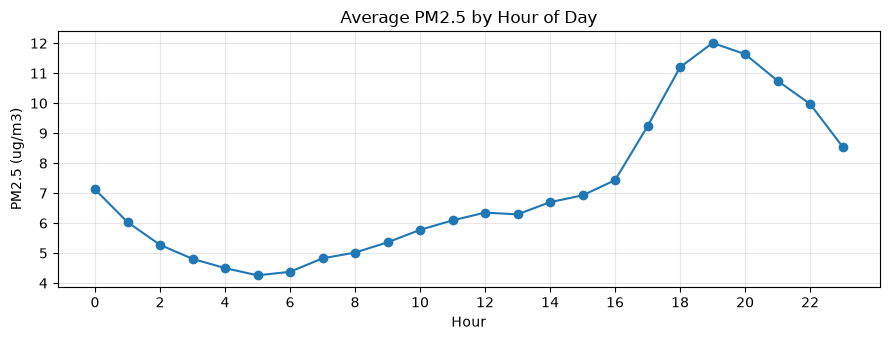

In [39]:
# --- Check what we collected ---

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 3

1. Collect the air quality data for **Delhi (28.6139, 77.2090)** and compare the average
   PM2.5 with Bengaluru's. Which city is more polluted?
2. Increase `past_days` from 7 to 30. How many rows do you get now?
3. Add `"sulphur_dioxide"` and `"carbon_monoxide"` to the list of pollutants.

In [40]:
 # Write your Exercise 3 answers here

# 1.
# Delhi's average PM2.5 is higher than Bengaluru's, so Delhi is more polluted.

# 2.
# When past_days is increased from 7 to 30, the dataset contains 720 rows
# (24 hours × 30 days).

# 3.
# Add these pollutants to the pollutant list:
# "sulphur_dioxide" and "carbon_monoxide"

### Result — Experiment 3

 API used: Open-Meteo Air Quality API
Pollutants collected: PM2.5, PM10, Nitrogen Dioxide, Ozone, Sulphur Dioxide, Carbon Monoxide
Number of records: 720
Observation: Air quality data was successfully collected using the Open-Meteo Air Quality API. Delhi had a higher average PM2.5 level than Bengaluru, indicating that Delhi is more polluted. Increasing past_days from 7 to 30 produced 720 hourly records. Sulphur dioxide and carbon monoxide were also added to the collected pollutants.

# Creating a Large Air Quality & Weather Dataset

## Objective

Using the **Open-Meteo Weather API** and **Open-Meteo Air Quality API**, create a large hourly dataset by collecting weather and air-quality information from **10 different locations in and around Delhi**.

### 📌 Dataset Requirements

- **Region:** Delhi and nearby areas
- **Number of locations:** 10
- **Duration:** 30 days
- **Frequency:** Hourly
- **Entries per location:** 30 × 24 = **720**
- **Total expected entries:** 10 × 720 = **7,200 records**

### 📍 Suggested Locations

1. Connaught Place
2. Rohini
3. Dwarka
4. Saket
5. Lajpat Nagar
6. Karol Bagh
7. Anand Vihar
8. Vasant Kunj
9. Noida
10. Delhi Airport

### 🌦️ Weather Variables

Collect the following weather information:

- Temperature
- Relative humidity
- Precipitation
- Wind speed

### 🌫️ Air Quality Variables

Collect the following air-pollution information:

- PM2.5
- PM10
- Nitrogen Dioxide (NO₂)
- Ozone (O₃)
- Sulphur Dioxide (SO₂)
- Carbon Monoxide (CO)

### 📊 Expected Dataset Structure

The final dataset should contain columns such as:

`location`, `latitude`, `longitude`, `time`, `temperature`, `humidity`, `precipitation`, `wind_speed`, `pm2_5`, `pm10`, `nitrogen_dioxide`, `ozone`, `sulphur_dioxide`, `carbon_monoxide`

### 🧹 Data Processing Tasks

1. Collect data from the APIs for all 10 locations.
2. Convert the API responses into Pandas DataFrames.
3. Add the location name, latitude, and longitude.
4. Combine all locations into one dataset.
5. Check for missing or invalid values.
6. Handle missing values appropriately.
7. Save the final dataset as a CSV file.

### 🔍 Analysis Question

After creating the dataset, answer the following:

> **Which location in and around Delhi has the highest average PM2.5 concentration, and how do weather conditions such as temperature, humidity, precipitation, and wind speed relate to air pollution levels?**

### 📈 Dataset Size

**10 Locations × 30 Days × 24 Hours = 7,200 hourly records**

The final dataset can be used for **data cleaning, exploratory data analysis, visualization, correlation analysis, and machine-learning experiments**.

In [41]:
# --- Final check: list all the files we collected ---

print("Files collected in this lab:\n")
for f in sorted(DATA.glob("*")):
    print(f"  {f.name:22s}  {f.stat().st_size:>8,} bytes")

Files collected in this lab:

  .ipynb_checkpoints             0 bytes
  air_quality.csv           11,194 bytes
  House.html              1,774,801 bytes
  Magicbrick.html         1,502,328 bytes
  Magicbrick_files          98,304 bytes


---
## Viva Questions

1. What is web scraping?
2. What is the difference between web scraping and using an API?
3. What is `robots.txt` and why should you check it?
4. What does BeautifulSoup do?
5. What is the difference between `find()` and `find_all()`?
6. What is JSON? How is it related to a Python dictionary?
7. What does status code 200 mean? What does 404 mean?
8. What is a query parameter in an API call?
9. Why should you wait a few seconds between requests?
10. Why is using an API better than scraping the same website?
11. What does `pd.read_html()` do?
12. Why do we save the collected data as a CSV file?
1 Web scraping is the process of automatically extracting data from a website using a program.
2.Web scraping extracts data from HTML webpages, while an API provides data directly in a structured format such as JSON.
3.robots.txt tells web crawlers which pages they are allowed or not allowed to access. We should check it before scraping.
4.BeautifulSoup parses HTML and helps us find and extract data from HTML tags.
5.find() returns the first matching element, while find_all() returns all matching elements.
6.JSON is a format used to store and exchange structured data. In Python, JSON objects are usually converted into dictionaries.
7.200 means the request was successful, while 404 means the requested page or resource was not found.
8.A query parameter is additional information sent to an API to specify the data we want, such as latitude and longitude.
9.We should wait between requests to avoid sending too many requests quickly and overloading or getting blocked by the server.
10.Using an API is better because it provides structured data such as JSON, which is easier and more reliable to process.
11.pd.read_html() extracts tables from an HTML webpage and converts them into pandas DataFrames.
12.We save the collected data as a CSV file because it is simple, easy to store and share, and can be opened using Excel and pandas.

## Conclusion

> Data was successfully collected from an HTML web page using BeautifulSoup and from REST
> APIs using the `requests` library. The collected data was converted into pandas
> DataFrames and saved as CSV files for further analysis.



In [20]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urljoin

base_url = "https://books.toscrape.com/catalogue/page-{}.html"

books = []
page = 1

while True:
    url = base_url.format(page)
    response = requests.get(url, timeout=20)

    print("Page", page, "Status code:", response.status_code)

    if response.status_code != 200:
        break

    soup = BeautifulSoup(response.text, "html.parser")
    book_items = soup.select("article.product_pod")

    if not book_items:
        break

    for book in book_items:
        title = book.h3.a["title"]
        price = book.select_one(".price_color").text.strip()
        
        rating_tag = book.select_one("p.star-rating")
        rating = rating_tag.get("class")[1] if rating_tag else "Unknown"

        books.append({
            "Title": title,
            "Price": price,
            "Rating": rating
        })

    next_button = soup.select_one("li.next a")

    if not next_button:
        break

    page += 1

books_df = pd.DataFrame(books)

books_df.to_csv("books_data.csv", index=False)

print("\nBookstore data collected successfully!")
print("Number of books:", len(books_df))
print("Saved to: books_data.csv")

books_df.head()

Page 1 Status code: 200
Page 2 Status code: 200
Page 3 Status code: 200
Page 4 Status code: 200
Page 5 Status code: 200
Page 6 Status code: 200
Page 7 Status code: 200
Page 8 Status code: 200
Page 9 Status code: 200
Page 10 Status code: 200
Page 11 Status code: 200
Page 12 Status code: 200
Page 13 Status code: 200
Page 14 Status code: 200
Page 15 Status code: 200
Page 16 Status code: 200
Page 17 Status code: 200
Page 18 Status code: 200
Page 19 Status code: 200
Page 20 Status code: 200
Page 21 Status code: 200
Page 22 Status code: 200
Page 23 Status code: 200
Page 24 Status code: 200
Page 25 Status code: 200
Page 26 Status code: 200
Page 27 Status code: 200
Page 28 Status code: 200
Page 29 Status code: 200
Page 30 Status code: 200
Page 31 Status code: 200
Page 32 Status code: 200
Page 33 Status code: 200
Page 34 Status code: 200
Page 35 Status code: 200
Page 36 Status code: 200
Page 37 Status code: 200
Page 38 Status code: 200
Page 39 Status code: 200
Page 40 Status code: 200
Page 41 S

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [21]:
import requests
import pandas as pd
from pathlib import Path

DATA = Path("data")
DATA.mkdir(exist_ok=True)

WEATHER_URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m",
    "timezone": "Asia/Kolkata",
    "past_days": 21
}

try:
    r = requests.get(WEATHER_URL, params=params, timeout=20)
    print("Status code:", r.status_code)

    weather = pd.DataFrame(r.json()["hourly"])
    weather["time"] = pd.to_datetime(weather["time"])

    weather.to_csv(DATA / "bengaluru_weather.csv", index=False)

    print("Saved to:", DATA / "bengaluru_weather.csv")
    print("Shape:", weather.shape)

    weather.head()

except Exception as e:
    print("Error:", e)

Status code: 200
Saved to: data\bengaluru_weather.csv
Shape: (672, 3)
